# Matplotlib Practice — Tasks 1 to 10

## About this task notebook

These ten problems ask you to apply everything from the Matplotlib sessions on your own. Each problem is a small, real-world data story — air-pollution records from world cities, a company's monthly sales, and year-by-year player stats — and your job is to pick the right chart, wire up the correct Pandas steps (filtering, grouping, aggregation) and then style the figure so it tells a clear story.

Before you write any plotting code, re-read the golden rule: **match the chart to the question**.

- *Time on the x-axis and one or more series on the y-axis?* → **line plot** (`plt.plot`).
- *Frequency / distribution of a single numeric column?* → **histogram** (`plt.hist`).
- *Relationship between two numeric columns?* → **scatter plot** (`plt.scatter`).
- *Contribution of each part to a whole?* → **pie chart** (`plt.pie`).
- *Comparing counts or aggregates across categories?* → **bar chart** (`plt.bar`).

The problems also repeat one routine that will become second nature: load a CSV with `pd.read_csv(...)`, filter rows with `df.query(...)` or boolean masks, and aggregate with `groupby(...)`. Practise reading the problem statement slowly and breaking it into (1) data preparation and (2) plotting.

A few plotting tips to keep handy while you work:

- Always add `plt.xlabel`, `plt.ylabel` and `plt.title` — a labelled, titled chart is a finished chart.
- `label=` gives each series a name; `plt.legend()` then draws the key.
- `linestyle` ('solid', 'dotted', 'dashdot'), `marker` ('o', '+', 'D') and `color` control the look of lines.
- `autopct='%0.1f%%'` prints percentage labels on pie slices; `explode` pulls a slice out.
- When drawing several bars or lines, offset the x positions (e.g. `-0.2`, `0`, `+0.2`) or use `bottom=` to stack them.

Write your solution under each `# code here` cell, run it, and check that the output looks the way the problem describes.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

plt.style.use('default')

## `Problem 1 to 5`:

Dataset link: https://tinyurl.com/2fe6vz4u

**Add a label to every axis and add a proper title for the charts. Also add proper labels if there are multiple representations.** Then, you can customize it as your wish.

### **`Problem-1:`** Draw a line plot of which, the x-axis is the "Year" and the y-axis is sum of "PM2.5" of two countries Iran and China. 

## Problem 1 — Line plot of PM2.5 over the years

**Concept.** A line plot is the right tool when the x-axis holds something continuous — here, `Year` — and you want to show how a value moves across it. We need **two** lines, one for Iran and one for China, where each point is the *sum* of PM2.5 for that country and that year.

**Hints.**
- The dataset has many rows per country-year, so aggregate first: filter with `df.query('Country == "Iran"')`, then `groupby('Year')['PM2.5'].sum()`. Each grouping produces a Series whose `.index` is the years and whose `.values` are the sums.
- Plot both series on the same axes with `plt.plot(index, values, label=..., linestyle=...)`.
- Give Iran a dashed line and China a dotted red line as requested.
- Finish with `xlabel`, `ylabel`, `title`, a legend and `plt.grid()`. The `xticks` choice makes every year clearly readable.

In [2]:
# code here
df = pd.read_csv('https://tinyurl.com/2fe6vz4u')
df.head()

,Unnamed: 0,Position,Country,City/Town,Year,PM2.5,Temporal coverage,PM10,Temporal coverage.1,Database version (year)
0,0,1,India,Kanpur,2016,173,>75%,319,NaN,2018
1,1,2,India,Faridabad,2016,172,>75%,316,NaN,2018
2,2,3,India,Gaya,2016,149,50% -< 75%,275,NaN,2018
3,3,4,India,Varanasi,2016,146,>75%,260,NaN,2018
4,4,5,India,Patna,2016,144,>75%,266,NaN,2018


In [3]:
iran_series = df.query('Country == "Iran"').groupby('Year')['PM2.5'].sum()
china_series = df.query('Country == "China"').groupby('Year')['PM2.5'].sum()

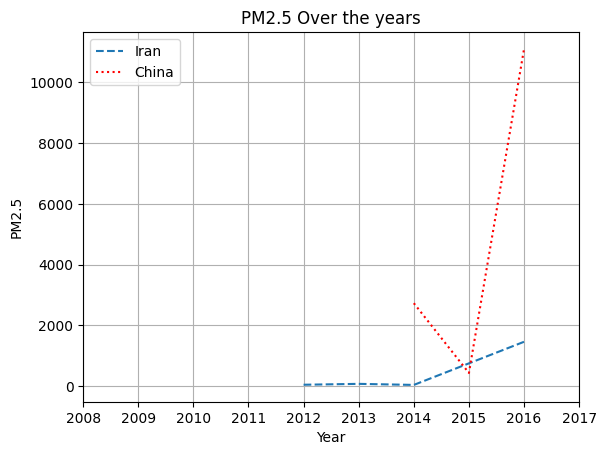

In [4]:
plt.plot(iran_series.index,iran_series.values,label='Iran',linestyle='dashed')
plt.plot(china_series.index,china_series.values,label='China',linestyle='dotted',color='red')
plt.xlabel('Year')
plt.ylabel('PM2.5')
plt.title('PM2.5 Over the years')
plt.xticks(df['Year'].value_counts().index)
plt.legend()
plt.grid()
plt.show()

### **`Problem-2:`** Draw a histogram of the  column "PM10" of which the y-axis represents the probability (see the documentation how to draw the probability). 

## Problem 2 — Histogram of PM10 as a probability

**Concept.** A histogram shows how a single numeric column is distributed: which values are common and which are rare. By default the bar height is a *count*; setting `density=True` (the older name for `stat='density'`) scales the bars so that their total area equals 1, turning the y-axis into an approximate **probability** — exactly what the problem asks for.

**Hints.**
- `plt.hist(df['PM10'], density=True, bins=50, facecolor='green', alpha=0.6)`.
- `bins` controls how many buckets; 50 gives a smooth shape.
- `alpha=0.6` adds slight transparency, `facecolor` sets the fill.
- Label the axes ('Bins', 'Probability') and add a title and grid.

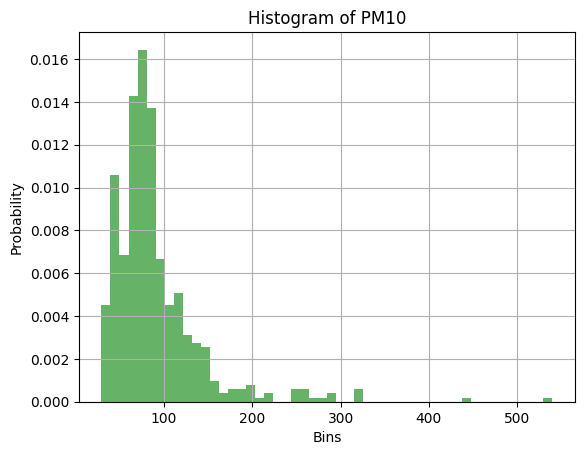

In [5]:
# code here
plt.hist(df['PM10'],density=True,bins=50,facecolor='green',alpha=0.6)
plt.xlabel('Bins')
plt.ylabel('Probability')
plt.title('Histogram of PM10')
plt.grid()
plt.show()

### **`Problem-3:`** Draw a scatter plot where x-axis represents "PM2.5" and y-axis represents "PM10" for two countries Poland and Chile.

## Problem 3 — Scatter of PM2.5 vs PM10 for two countries

**Concept.** A scatter plot examines the *relationship* between two numeric columns — do high PM2.5 readings come with high PM10 readings? To compare two countries on one figure, filter the data into two small DataFrames and call `plt.scatter` twice, using `label` plus distinct `marker` and `color` so the legend can tell them apart.

**Hints.**
- Build the two frames with `df.query("Country == 'Chile'")` and the same for Poland.
- `plt.scatter(chile_df['PM2.5'], chile_df['PM10'], marker='+', color='red', label='Chile')`.
- Use marker `'D'` (diamond) and black for Poland so the groups separate visually.
- Always add labels, a title, `plt.legend()` and a grid.

In [6]:
# code here
chile_df = df.query("Country == 'Chile'")
poland_df = df.query("Country == 'Poland'")

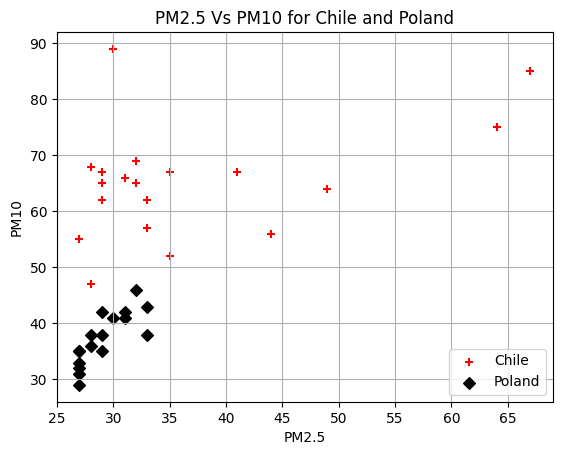

In [7]:
plt.scatter(chile_df['PM2.5'],chile_df['PM10'],marker="+",color='red',label='Chile')
plt.scatter(poland_df['PM2.5'],poland_df['PM10'],marker="D",color='black',label='Poland')
plt.xlabel('PM2.5')
plt.ylabel('PM10')
plt.title('PM2.5 Vs PM10 for Chile and Poland')
plt.legend()
plt.grid()
plt.show()

### **`Problem-4:`** Draw a pie chart of top 5 most frequent countries.

## Problem 4 — Pie chart of the top 5 countries

**Concept.** A pie chart answers the question "what share of the whole does each part own?". You need a single Series of counts — `value_counts()` counts how many rows belong to each `Country` — and `.head()` keeps only the top five.

**Hints.**
- `freq_ser = df['Country'].value_counts().head()` gives you counts as values and countries as index.
- `plt.pie(freq_ser, labels=freq_ser.index, autopct='%0.1f%%')` — the `Series` passes both numbers and labels at once.
- `autopct` prints each slice's percentage. Remember that pies are best with a handful of slices only.

In [8]:
# code here
freq_ser = df['Country'].value_counts().head()

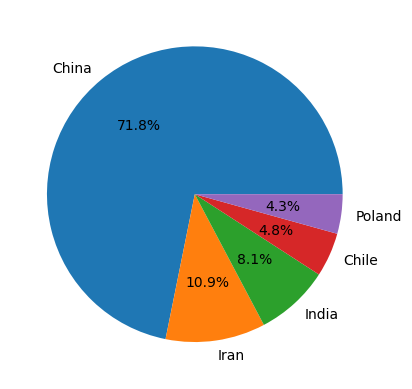

In [9]:
plt.pie(freq_ser,labels=freq_ser.index,autopct='%0.1f%%')
plt.show()

### **`Problem-5:`** Draw a bar chart which represents the counts of top 5 most frequent countries.



## Problem 5 — Bar chart of the top 5 countries

**Concept.** A bar chart compares *magnitudes* across categories: each country becomes a bar whose height equals its count. Unlike a pie, bars make small differences easy to compare because you judge lengths, not angles.

**Hints.**
- Reuse the exact same `freq_ser` from Problem 4 — the index goes to x and the values to y.
- `plt.bar(freq_ser.index, freq_ser)` draws the bars automatically with the country names as tick labels.
- Label the axes ('Country', 'Frequency Count') and add a title.
- Try both Problem 4 and 5 charts and notice how the bar chart conveys the same information more clearly.

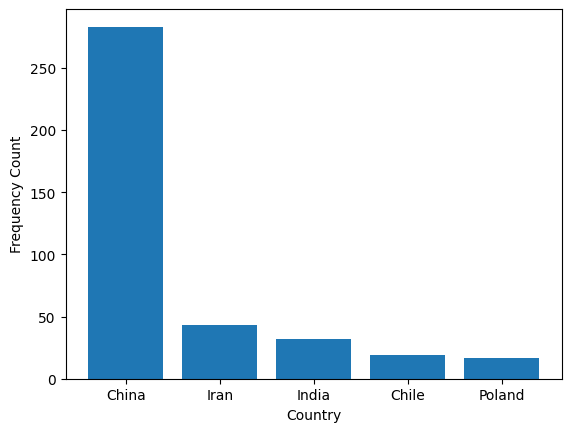

In [10]:
# code here
plt.bar(freq_ser.index,freq_ser)
plt.xlabel('Country')
plt.ylabel('Frequency Count')
plt.show()

##`Problem 6-10`
Data Set - https://docs.google.com/spreadsheets/d/e/2PACX-1vTJh6X4_mqixWsfK9mgkllGQkKYW9Wj9kOIMGY2uYsWeS8n5np87DO-SDGQWJ1HXEnxiOVFVzYFYEcR/pub?gid=558678488&single=true&output=csv

This is a Sales data of any company in a Year.


###`Problem-6`
Show a line plot of Total Profit for each month with below styling.
* Dotted Line
* Line Color Blue
* Show Legend at top left
* Circle Marker

## Problem 6 — Line plot of monthly total profit

**Concept.** This is a classic time-series line chart with **styling requirements**. The dataset is company sales with one row per month; `total_profit` is the column to trace against `month_number`. Styling arguments on the same `plt.plot` call control the whole look: `color='b'` (blue), `marker='o'` (circle at each month), `linestyle='dotted'` and `label` for the legend.

**Hints.**
- `plt.plot(df['month_number'], df['total_profit'], label='Month on month Profit', color='b', marker='o', linestyle='dotted')`.
- The legend must sit at the top-left: `plt.legend(loc='upper left')`.
- Add x/y labels and a title such as 'Company sales profit'.

In [11]:
# code here
df = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vTJh6X4_mqixWsfK9mgkllGQkKYW9Wj9kOIMGY2uYsWeS8n5np87DO-SDGQWJ1HXEnxiOVFVzYFYEcR/pub?gid=558678488&single=true&output=csv')
df

,month_number,facecream,facewash,toothpaste,bathingsoap,shampoo,moisturizer,total_units,total_profit
0,1,2500,1500,5200,9200,1200,1500,21100,211000
1,2,2630,1200,5100,6100,2100,1200,18330,183300
2,3,2140,1340,4550,9550,3550,1340,22470,224700
3,4,3400,1130,5870,8870,1870,1130,22270,222700
4,5,3600,1740,4560,7760,1560,1740,20960,209600
5,6,2760,1555,4890,7490,1890,1555,20140,201400
6,7,2980,1120,4780,8980,1780,1120,29550,295500
7,8,3700,1400,5860,9960,2860,1400,36140,361400
8,9,3540,1780,6100,8100,2100,1780,23400,234000
9,10,1990,1890,8300,10300,2300,1890,26670,266700


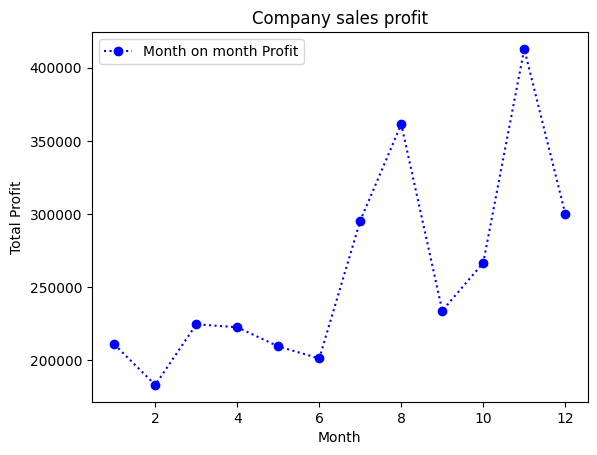

In [12]:
plt.plot(df['month_number'],df['total_profit'],label='Month on month Profit',color='b',marker='o',linestyle='dotted')
plt.xlabel('Month')
plt.ylabel('Total Profit')
plt.title('Company sales profit')
plt.legend(loc="upper left")
plt.show()

###`Problem-7` 
Show sales of each product in march month as pie chart. 
* Show Percentage value 
* Give Title "Sales in March"
* Explode ToothPaste with shadow

## Problem 7 — Pie chart of March sales, toothpaste exploded

**Concept.** A pie can show one row's sales: which product, in a single month, contributed how much to total sales. The `explode` list pulls one slice (toothpaste) away from the center so it stands out, and `autopct` adds percentages. `shadow=True` gives the pie a soft depth.

**Hints.**
- Isolate March and take product columns only: `df[df['month_number'] == 3].iloc[:, 1:7]`.
- `.stack()` folds those columns into one series, so `labels` and `values` come from its index and values — the cleanest way to label each product.
- `plt.pie(values, labels=labels, autopct='%0.1f%%', explode=[0,0,0.1,0,0,0], shadow=True)` puts toothpaste (third) on its own.
- `plt.title('Sales in March')` as required.

In [13]:
# code here
labels = df[df['month_number'] == 3].iloc[:,1:7].stack().index.get_level_values(1)
values = df[df['month_number'] == 3].iloc[:,1:7].stack().values

In [14]:
labels

Index(['facecream', 'facewash', 'toothpaste', 'bathingsoap', 'shampoo',
       'moisturizer'],
      dtype='str')

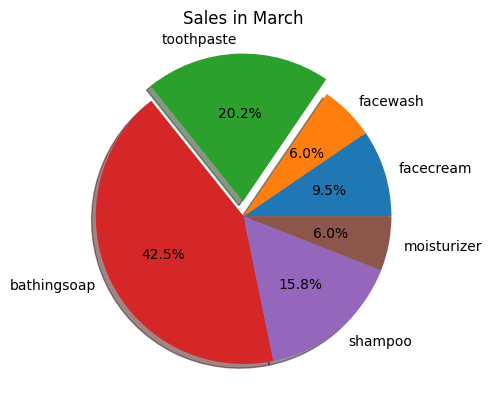

In [15]:
plt.pie(values,labels=labels,autopct='%0.1f%%',explode=[0,0,0.1,0,0,0],shadow=True)
plt.title("Sales in March")
plt.show()

###`Problem-8` Multiline Plot of all products sales.
* Give different styes for each products
* Add legend at top right

## Problem 8 — Multiline plot of all product sales

**Concept.** When you want to compare several series over the same x-axis, call `plt.plot` once per series — all calls draw onto the same axes and the `label` argument names each one. The legend at top-right (`loc='upper right'`) then unlocks the key.

**Hints.**
- Build `monthList = df['month_number'].tolist()` once and reuse it for every line.
- Give each product its own style: `facecream` is dotted with round markers, `facewash` is dashed, `shampoo` is dashdot, and the rest solid — mix `linestyle`, `marker` and `linewidth` so the lines are distinguishable even in black-and-white.
- Set `plt.xticks(monthList)` so every month appears.
- Finish with labels, legend `loc='upper right'` and `plt.title('Sales data')`.

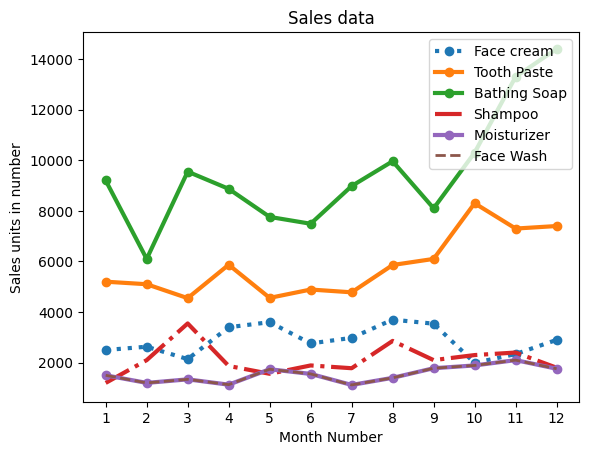

In [16]:
# code here
monthList  = df['month_number'].tolist()

plt.plot(monthList, df['facecream'],   label = 'Face cream', linestyle='dotted', marker='o', linewidth=3)
plt.plot(monthList, df['toothpaste'], label = 'Tooth Paste', marker='o', linewidth=3)
plt.plot(monthList, df['bathingsoap'], label = 'Bathing Soap', marker='o', linewidth=3)
plt.plot(monthList, df['shampoo'], label = 'Shampoo', linestyle='dashdot', linewidth=3)
plt.plot(monthList, df['moisturizer'], label = 'Moisturizer', marker='o', linewidth=3)
plt.plot(monthList, df['facewash'],   label = 'Face Wash',  linestyle='dashed', linewidth=2)


plt.xlabel('Month Number')
plt.ylabel('Sales units in number')
plt.legend(loc='upper right')
plt.xticks(monthList)
plt.title('Sales data')
plt.show()

###`Problem-9` Show Quarter wise Sales data for all products as multi Bar chart.


## Problems 9 & 10 — Quarter-wise grouped and stacked bars

**Concept.** When sales are monthly but the question is *per quarter*, the first step is data preparation: turn `month_number` into real dates with `pd.to_datetime`, extract the quarter with `.dt.quarter`, and aggregate with `groupby(...)`. Every group (Q1-Q4) then holds the total per product, ready for either a **grouped** or a **stacked** bar chart.

**Hints for Problem 9 (grouped).** Grouped bars place one thin bar per product at slightly shifted x positions. Loop over the six product columns: start `i = -1` and draw `plt.bar(final_df.index + i, final_df[col], width=0.15, label=col)`, then shift `i` by `-0.15` each time. `plt.xticks(final_df.index - 1.4, final_df.index)` re-centers the quarter labels.

**Hints for Problem 10 (stacked).** A stacked bar accumulates: every bar after the first is drawn `bottom=sum(all_cols)`, where `all_cols` accumulates the columns already drawn. The last cell shows the trick's key check — `sum(all_cols)` adds the pandas Series to verify the total. Stacked bars are ideal when each product's *contribution* to the quarter total matters.

In [17]:
# code here
df['date'] = pd.to_datetime(['2020-{}-01'.format(month) for month in df['month_number']])

In [22]:
final_df = df.groupby(df['date'].dt.quarter)

In [23]:
final_df

In [24]:
i = -1
for col in final_df.columns[1:7]:
  plt.bar(final_df.index + i,final_df[col],width=0.15,label=col)
  i = i - 0.15

plt.xticks(final_df.index-1.4,final_df.index)
plt.xlabel('Product')
plt.ylabel('Sales')
plt.legend()
plt.show()

AttributeError: 'DataFrameGroupBy' object has no attribute 'columns'

In [25]:
final_df.iloc[:,1:7]

AttributeError: 'DataFrameGroupBy' object has no attribute 'iloc'

###`Problem-10` Plot Stacked Bar chart quarter wise for each product.

In [19]:
# code here
final_df

NameError: name 'final_df' is not defined

In [20]:
all_cols = []

for col in final_df.columns[1:7]:
  if len(all_cols) == 0:
    plt.bar(final_df.index,final_df[col],label=col)
  else:
    plt.bar(final_df.index,final_df[col],bottom=sum(all_cols),label=col)
  all_cols.append(final_df[col])

plt.xticks(final_df.index - 0.02, final_df.index)
plt.legend()
plt.show()

NameError: name 'final_df' is not defined

In [21]:
sum(all_cols)

0

## Summary

In this task notebook you practised the complete Matplotlib workflow on real data. For time series you built line plots with full styling control (`color`, `linestyle`, `marker`, `legend` locations); for distributions you used histograms with `density=True` to get probabilities; for two numeric columns you compared groups in a single scatter; and for categorical counts you used pie and bar charts, including grouped and stacked variants via x-offsets and the `bottom=` parameter. Along the way you sharpened essential Pandas skills: `query`, boolean masks, `value_counts`, `to_datetime`, `groupby` and `.dt.quarter`. The pattern in every problem was the same — prepare the data first, then choose and style the chart to answer the question — and that is exactly the habit you will carry into every future analysis.